## 1. Import Libraries and Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder,StandardScaler
from sklearn.feature_selection import SelectKBest

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

from module_function import (cross_validate_model,plot_all_modelsRegression_predictions,
                             evaluate_models_Regression,feature_importance,plot_residuals,Hyperparameter_Tuning,plot_tuned_feature_importance)

import warnings
warnings.filterwarnings("ignore")

import pickle

In [2]:
df = pd.read_csv('dataset/forestfires_CLEANING.csv')
df_x = df.drop(columns='area')
df_y = df['area']

In [3]:
X_train,X_test,y_train,y_test = train_test_split(df_x,df_y,test_size=0.2,random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 240 samples
Test set: 60 samples


## 2. Feature Scaling

In [4]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

base_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
    ]   
)

## 3.Pipeline All Models Regression

In [5]:
n = 10
regresi_pipelines = {
    'Decision Tree Regressor': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=mutual_info_regression, k=n)),
        ('model', DecisionTreeRegressor(max_depth=5, random_state=42))
    ]),
    
    'Random Forest Regressor': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=mutual_info_regression, k=n)),
        ('model', RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42))
    ]),
    
    'Extra Trees Regressor': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=mutual_info_regression, k=n)),
        ('model', ExtraTreesRegressor(n_estimators=100, max_depth=5, random_state=42))
    ]),
    
    'Gradient Boosting Regressor': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=mutual_info_regression, k=n)),
        ('model', GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42))
    ]),
    
    'XGBoost Regressor': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=mutual_info_regression, k=n)),
        ('model', XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=42))
    ]),
    
    'LightGBM Regressor': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=mutual_info_regression, k=n)),
        ('model', LGBMRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42, verbosity=-1))
    ]),
    
    'CatBoost Regressor': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=mutual_info_regression, k=n)),
        ('model', CatBoostRegressor(iterations=100, learning_rate=0.05, depth=3, random_state=42, verbose=0))
    ])
}

## 4.Analysis Model Sebelum Cross-Validate

In [6]:
predictions_dict = {}
for model_name, pipeline in regresi_pipelines.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    predictions_dict[model_name] = y_pred

df_report = evaluate_models_Regression( model_dict=predictions_dict, y_test=y_test)
df_report.sort_values(by='R2-Score', ascending=False)

Menguji model: Decision Tree Regressor
Menguji model: Random Forest Regressor
Menguji model: Extra Trees Regressor
Menguji model: Gradient Boosting Regressor
Menguji model: XGBoost Regressor
Menguji model: LightGBM Regressor
Menguji model: CatBoost Regressor

Proses Training Selesai!


,Model,R2-Score,MAE,MSE,RMSE
2,Extra Trees Regressor,-0.1241,2.8633,12.0966,3.4780
6,CatBoost Regressor,-0.1825,2.9782,12.7251,3.5672
1,Random Forest Regressor,-0.2048,2.9919,12.9648,3.6007
5,LightGBM Regressor,-0.2597,3.1021,13.5553,3.6818
4,XGBoost Regressor,-0.3553,3.1565,14.5839,3.8189
3,Gradient Boosting Regressor,-0.3795,3.0630,14.8441,3.8528
0,Decision Tree Regressor,-0.7706,3.1807,19.0533,4.3650


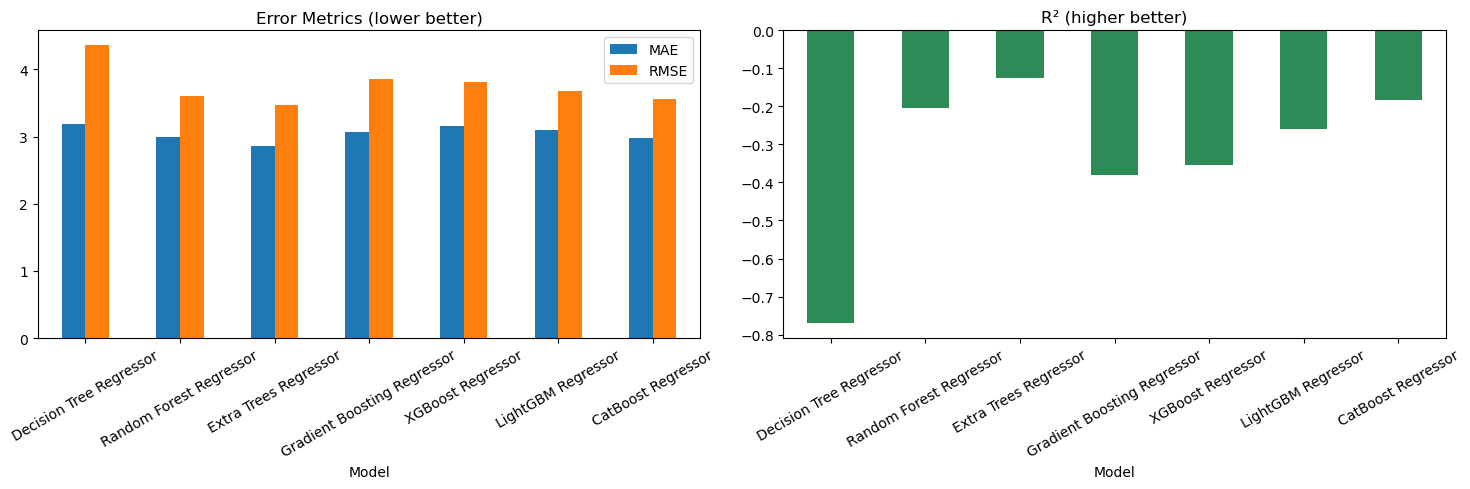

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df_report.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Error Metrics (lower better)')
axes[0].tick_params(axis='x', rotation=30)

df_report.set_index('Model')[['R2-Score']].plot(kind='bar', ax=axes[1], color='seagreen', legend=False)
axes[1].set_title('R² (higher better)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 5.Analysis Model Sesudah Cross-Validate

In [8]:
df_hasil_perbandingan = cross_validate_model(models_dict=regresi_pipelines, X=X_train, y=y_train, cv_folds=10, mode='regression')
df_hasil_perbandingan.sort_values(by='R2-Score', ascending=False)

=== MENJALANKAN 10-FOLD CROSS VALIDATION (REGRESI) ===

Menguji model: Decision Tree Regressor
Menguji model: Random Forest Regressor
Menguji model: Extra Trees Regressor
Menguji model: Gradient Boosting Regressor
Menguji model: XGBoost Regressor
Menguji model: LightGBM Regressor
Menguji model: CatBoost Regressor

Proses CV Selesai!


,Model,R2-Score,MAE,MSE,RMSE
6,CatBoost Regressor,-0.264496,2.836382,14.543810,3.813635
5,LightGBM Regressor,-0.306979,2.834340,14.961642,3.868028
2,Extra Trees Regressor,-0.427318,2.936662,15.420897,3.926945
3,Gradient Boosting Regressor,-0.454052,2.900831,16.072498,4.009052
1,Random Forest Regressor,-0.532249,2.997537,16.041844,4.005227
0,Decision Tree Regressor,-0.663697,2.801860,18.149149,4.260182
4,XGBoost Regressor,-0.710082,2.984486,16.802798,4.099122


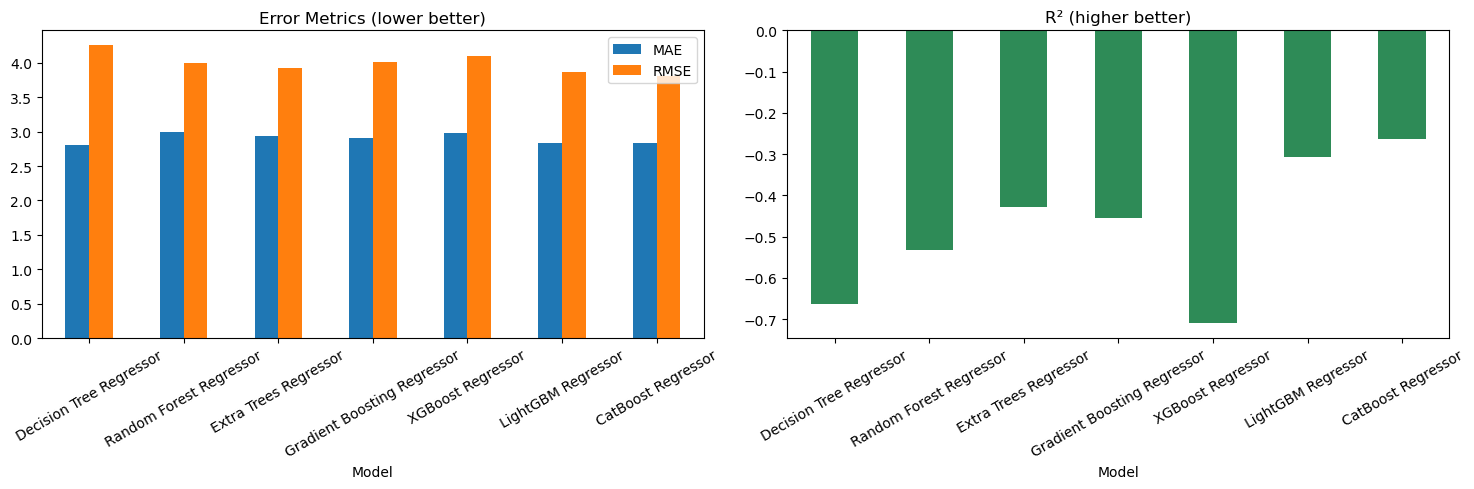

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df_hasil_perbandingan.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Error Metrics (lower better)')
axes[0].tick_params(axis='x', rotation=30)

df_hasil_perbandingan.set_index('Model')[['R2-Score']].plot(kind='bar', ax=axes[1], color='seagreen', legend=False)
axes[1].set_title('R² (higher better)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()
